# 05 · Resilience and recovery

**Story so far:** the corpus is enriched and scored in parallel on a warm pool
([03](./03-processing-at-scale.ipynb)) and feature iteration is cheap
([04](./04-caching-and-reproducibility.ipynb)). None of that survives contact with
production unless the pipeline *expects* failure: flaky vendor APIs, shards 100× bigger
than the median, spot nodes reclaimed mid-run, pods that die two hours into a job.

Flyte's unit of retry is the **task attempt**: an attempt either produces outputs or
fails, and the platform re-runs the whole thing. This chapter is about making that
re-run cheap — and, where the work is long or has external side effects, about not
starting from zero at all.

**Learning goals**

1. Configure retries and two-dimensional timeouts (runtime vs queue wait)
2. Recover from OOM by re-invoking with more memory, in code
3. Persist progress *across attempts* with `flyte.Checkpoint`
4. Replay expensive external calls *within* an attempt with `@flyte.trace`
5. Tell those last two apart, and know which one a given failure needs

In [ ]:
import asyncio
from datetime import timedelta
from typing import List

import flyte
from flyte import Timeout

flyte.init_from_config()

env = flyte.TaskEnvironment(
    name="resilience",
    resources=flyte.Resources(cpu="1", memory="1Gi"),
)

In [ ]:
# The same 200 synthetic reviews as chapter 03, so this chapter stands alone.
import random


def make_reviews(n: int, seed: int = 7) -> list:
    rng = random.Random(seed)
    products = ["espresso machine", "trail shoes", "headphones", "air fryer"]
    out = []
    for i in range(n):
        p = rng.choice(products)
        out.append({"id": i, "product": p, "stars": rng.randint(1, 5),
                    "text": f"review {i} about the {p}"})
    return out


REVIEWS = make_reviews(200)
len(REVIEWS)

## 1. Retries and timeouts

- `retries=3` → up to 4 attempts total. Applies to *task* failures (exceptions, OOM,
  node loss).
- `timeout` bounds two different things, and it pays to bound both:
  - `max_runtime`: how long an attempt may execute
  - `max_queued_time`: how long it may **wait for capacity** before Flyte gives up.
    This is your automatic detector for "the cluster has no free capacity": instead of a
    run silently pending for hours, you get a clear, attributable failure.

> 💬 **Discuss:** what should `max_queued_time` be for this customer's heaviest jobs?
> Which events in their environment (spot exhaustion, quota, autoscaler limits) would
> trip it, and who should hear about it when it fires?

In [ ]:
@env.task(
    retries=3,
    timeout=Timeout(
        max_runtime=timedelta(minutes=10),
        max_queued_time=timedelta(minutes=5),
    ),
)
async def call_moderation_api(review: dict) -> dict:
    import random
    if random.random() < 0.2:
        raise ConnectionError(f"transient failure moderating review {review['id']}")
    return {**review, "moderation": "clean"}

In [ ]:
# retries=3 recovers from the transient failures; some actions show a retry
# before succeeding (visible in the run timeline).
@env.task
async def moderate_all(reviews: List[dict]) -> List[dict]:
    out: List[dict] = []
    async for r in flyte.map.aio(call_moderation_api, reviews, return_exceptions=True):
        if isinstance(r, Exception):
            raise r
        out.append(r)
    return out


run = flyte.run(moderate_all, reviews=REVIEWS[:6])
print(run.url)
run.wait()
run.outputs()

The action recovered from a failure by retrying:

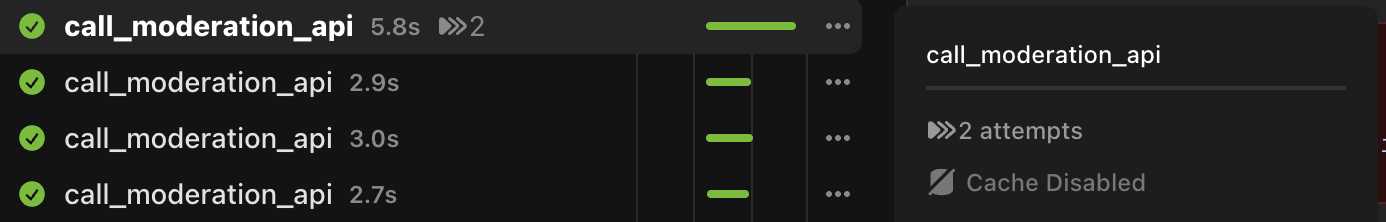

## 2. Recovering from OOM with more memory

The classic failure in data pipelines: input sizes vary 100×, so either you over-provision
everything or some shards OOM. In v2 the pipeline itself can catch
`flyte.errors.OOMError` and re-invoke with bigger resources: pay for the big pod only
when a skewed shard needs it:

In [ ]:
import flyte.errors


@env.task
async def build_shard_index(reviews_in_shard: int) -> int:
    # Hold ~1kB per review in one contiguous buffer to simulate size-dependent memory use.
    # (A list of `b"x" * 1024` would NOT work: that expression is a compile-time constant,
    # so every element shares one object and the list costs ~pointers, not ~1kB each.)
    data = bytearray(reviews_in_shard * 1024)
    return len(data) // 1024


@env.task
async def resilient_index(reviews_in_shard: int) -> int:
    try:
        return await build_shard_index(reviews_in_shard=reviews_in_shard)
    except flyte.errors.OOMError:
        print("OOM at 1Gi, retrying this shard with 4Gi")
        return await build_shard_index.override(
            resources=flyte.Resources(cpu="1", memory="4Gi")
        )(reviews_in_shard=reviews_in_shard)

In [ ]:
# Happy path: 100k "reviews" (~100MB) fits the 1Gi box and runs straight through.
#run = flyte.run(resilient_index, reviews_in_shard=100_000)
#print(run.url)
#run.wait()
#print(run.outputs())

# To WATCH the recovery: 2M reviews (~2GB) OOMs the 1Gi first attempt; the except
# branch retries at 4Gi and succeeds (~1-2 min; the first attempt fails on purpose).
run = flyte.run(resilient_index, reviews_in_shard=2_000_000)
print(run.url); run.wait(); print(run.outputs())

This composes with `retries`: transient infrastructure failures use the retry budget,
while the OOM path changes the resources rather than retrying the same doomed
configuration. In operational reviews this is the cleanest way to separate **platform
errors** (node lost, image pull) from **user-code errors** (OOM at any size, exceptions).
More in [appendix B](./appendix/B-observability-and-debugging.md).

## 3. Saving progress across attempts: `flyte.Checkpoint`

Everything so far restarts the attempt from zero. That is fine for a 30-second enrichment
and brutal for a two-hour fit that dies at minute 110 — especially on spot capacity, where
reclamation is routine rather than exceptional.

`flyte.Checkpoint` gives a task a durable slot in the object store that **survives across
attempts of the same action**. You get it from the task context:

| | |
|---|---|
| `cp = flyte.ctx().checkpoint` | `None` if the deployment gave this task no checkpoint prefix |
| `cp.prev_exists()` | is there a previous attempt to resume from? |
| `await cp.load()` | download that attempt's blob; returns a local path, or `None` if there is nothing to restore |
| `await cp.save(data)` | upload `bytes`, a file path, or a whole directory |

What comes back from `load()` depends on what you saved: **bytes or a single file** land at
`cp.path / "payload"` (which is what's returned), while a **directory** is stored as a gzip
tar and unpacked under `cp.path`, and that directory is returned instead. In ordinary
`def` tasks use `load_sync()` / `save_sync()`.

The task below fits a model epoch by epoch, saves the epoch counter after each one, and
deliberately loses its node partway through. The retry picks up where it left off:

In [ ]:
@env.task(retries=3)
async def fit_model(epochs: int = 8, crash_at: int = 3) -> int:
    cp = flyte.ctx().checkpoint

    start = 0
    if cp is not None and cp.prev_exists():
        restored = await cp.load()                  # None if the last attempt saved nothing
        if restored is not None:
            start = int(restored.read_text())
            print(f"resuming at epoch {start}")

    for epoch in range(start, epochs):
        await asyncio.sleep(1)                      # stand in for one epoch of real training
        if cp is not None:
            await cp.save(str(epoch + 1).encode())  # bytes -> a single checkpoint object

        # Simulate losing the node mid-fit, but only on the first attempt.
        if epoch == crash_at and start <= crash_at:
            raise RuntimeError(f"node lost at epoch {epoch}")

    return epochs

In [ ]:
# Attempt 1 dies at epoch 3 (after saving it); attempt 2 restores the counter and runs
# epochs 4-7. Open the URL: the action shows two attempts, and the second one's logs
# start with "resuming at epoch 4" instead of redoing the first four epochs.
run = flyte.run(fit_model, epochs=8, crash_at=3)
print(run.url)
run.wait()
print(run.outputs())

Real frameworks save a checkpoint *directory*, not a counter, and the pattern is the same:
`await cp.save(ckpt_dir)` tars the tree, `await cp.load()` returns the restored root, and
`flyte.latest_checkpoint(root, "**/last.ckpt")` picks the newest file out of it (the default
glob matches Lightning's layout; pass another for a different one). That is what makes long
GPU training on spot capacity ([06](./06-training-at-scale.ipynb)) survivable.

Rules of thumb:

- Checkpoint on a **time** budget, not every step: often enough that a lost attempt is
  cheap, rarely enough that the upload isn't the job
- Save something you can **resume from deterministically** — step counter plus weights and
  optimizer state, not just weights
- `load()` returning `None` is normal (first attempt, or nothing saved yet); always handle it

## 4. Replaying calls within an attempt: `@flyte.trace`

Checkpoints resume your *own* progress. The other half of the problem is external side
effects. Our moderation pass has that shape: **submit** a batch to the vendor API, then
**wait** for it to finish — and a retry must not re-submit. `@flyte.trace` on an `async`
helper makes each call a **recorded step**: on retry, completed calls are replayed from the
record instead of re-executed, so there are no double-submissions, and each call shows up
in the UI timeline.

In [ ]:
@flyte.trace
async def submit_moderation_batch(ids: List[int]) -> str:
    # e.g. POST /batches to the moderation vendor; returns a job handle
    await asyncio.sleep(0.1)
    return f"job-{min(ids)}-{max(ids)}"


@flyte.trace
async def wait_for_moderation(job_id: str) -> int:
    # e.g. poll until the vendor finishes
    await asyncio.sleep(0.2)
    return len(job_id)


@env.task(retries=3)
async def moderate_corpus(review_ids: List[int]) -> int:
    job = await submit_moderation_batch(review_ids)     # traced step 1
    return await wait_for_moderation(job)               # traced step 2

In [ ]:
# The traced submit/wait helpers show up as steps inside the task's timeline.
run = flyte.run(moderate_corpus, review_ids=[r["id"] for r in REVIEWS[:6]])
print(run.url)
run.wait()
run.outputs()

If the pod dies while polling, the retry **skips re-submission**: the submit result is
replayed from the trace. Rules of thumb:

- Only `async def` helpers can be traced
- Trace non-deterministic/external calls; don't trace cheap pure functions
- Keep traced inputs/outputs small and serializable

## 5. Which one do I need?

| | `flyte.Checkpoint` | `@flyte.trace` |
|---|---|---|
| The unit | Your bytes / file / directory | One function call and its result |
| You manage | The format, and when to save | Nothing — the decorator records the call |
| Right for | Long computations with internal progress: training epochs, a growing index, a multi-pass ETL | Non-deterministic or side-effecting calls: vendor APIs, job submissions, LLM calls |
| Wrong for | Cheap steps — the upload costs more than redoing the work | Cheap pure functions; large or unserializable payloads |
| Constraint | Sync tasks use the `*_sync` variants | `async def` helpers only |

Both survive across attempts of the same action, both compose with `retries`, and both earn
their keep fastest on **spot** capacity, where interruption is routine rather than
exceptional: pair spot workers with a periodic checkpoint and traced external calls, and a
reclaimed node costs you a few minutes instead of the whole run
([04 §4](./04-caching-and-reproducibility.ipynb)).

> 💬 **Discuss:** pick the customer's longest-running task. Where would its checkpoint go,
> what would it contain, and how much work would a reclaimed spot node cost them today?

**Story checkpoint:** the pipeline now expects failure — flaky APIs retry, skewed shards get
a bigger pod, long jobs resume where they died, and vendor submissions never double-fire.
The scores and features are ready; time to train the real model.

## Further reading

- Union docs: [Traces](https://www.union.ai/docs/v2/union/user-guide/task-programming/traces/) · [Build tasks](https://www.union.ai/docs/v2/union/user-guide/task-programming/)
- Debugging a failed run: [appendix B](./appendix/B-observability-and-debugging.md)
- Next: [06-training-at-scale](./06-training-at-scale.ipynb): training and hyperparameter
  search, including when a distributed framework (Ray) earns its place